# 📧 Phishing and Malicious Email Classification Using LSTM

### Deep Learning Applications — ELA-1

**Student Name:** Nithya Siripurapu
**Roll Number:** *23071A67B4*  
**Branch:** CSE – Data Science  
**Institution:** VNR VJIET  

---

### Project Overview

This project develops a deep learning-based text classification system for detecting phishing and malicious emails. A real-world phishing email dataset is used to train a Long Short-Term Memory (LSTM) neural network.

The system processes the textual content of an email and classifies it into one of two categories:

- **Legitimate Email**
- **Phishing / Malicious Email**

The complete pipeline includes text preprocessing, tokenization, sequence padding, LSTM-based classification, and performance evaluation.

In [1]:
# Import libraries required for data processing, visualization,
# model development, and performance evaluation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load the real-world phishing email dataset.

DATA_PATH = "/content/phishing_email.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (6502, 2)


In [3]:
print(df.columns.tolist())
print(df.head())

['text_combined', 'label']
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...    0.0
1  nom actual vols 24 th forwarded sabrae zajac h...    0.0
2  enron actuals march 30 april 1 201 estimated a...    0.0
3  hpl nom may 30 2001 see attached file hplno 53...    0.0
4  hpl nom june 1 2001 see attached file hplno 60...    0.0


## 3. Dataset Overview

The project uses the `phishing_email.csv` dataset. The loaded dataset contains 6,502 labelled email samples before data cleaning.

The dataset consists of two columns:

- **`text_combined`** — The textual content of the email.
- **`label`** — The target class indicating whether the email is legitimate or phishing/malicious.

Before training the model, the dataset is examined for missing values, duplicate records, and class distribution.

In [4]:
# Check for missing values and duplicate email records.

print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values:
text_combined    0
label            1
dtype: int64

Number of duplicate rows: 201


## 4. Data Cleaning

Data cleaning is performed before training the deep learning model.

The following steps are applied:

- Remove samples with missing email text or labels.
- Remove duplicate records.
- Ensure that the email text is stored as a string.
- Reset the dataframe index after cleaning.

These steps help prevent invalid or redundant samples from affecting model training.

In [5]:
# Remove rows with missing text or labels.
df = df.dropna(subset=["text_combined", "label"])

# Remove duplicate records.
df = df.drop_duplicates()

# Ensure email content is represented as text.
df["text_combined"] = df["text_combined"].astype(str)

# Reset the dataframe index.
df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)
print("Remaining missing values:")
print(df.isnull().sum())

Dataset shape after cleaning: (6300, 2)
Remaining missing values:
text_combined    0
label            0
dtype: int64


In [6]:
# Examine the target labels present in the dataset.

print("Unique labels:")
print(df["label"].unique())

print("\nClass distribution:")
print(df["label"].value_counts())

Unique labels:
[0. 1.]

Class distribution:
label
0.0    4948
1.0    1352
Name: count, dtype: int64


## 5. Class Distribution

The dataset contains two classes: legitimate emails and phishing/malicious emails.

The class distribution is visualized below to determine whether the dataset is significantly imbalanced. A relatively balanced distribution is desirable because it allows the model to learn both classes effectively.

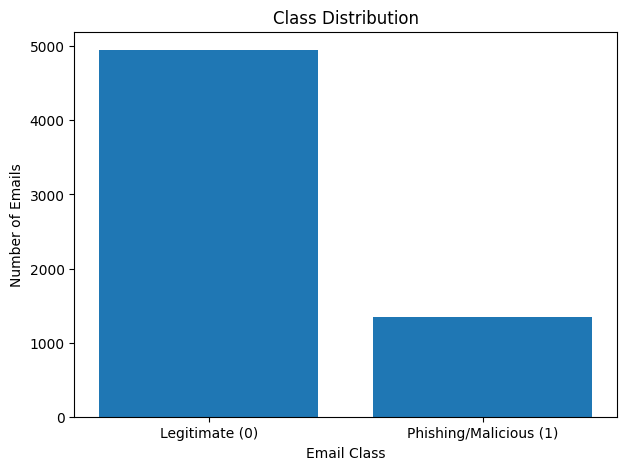

Legitimate emails: 4948
Phishing/Malicious emails: 1352


In [7]:
# Visualize the distribution of legitimate and phishing/malicious emails.

label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Legitimate (0)", "Phishing/Malicious (1)"],
    label_counts.values
)

plt.xlabel("Email Class")
plt.ylabel("Number of Emails")
plt.title("Class Distribution")

plt.show()

print("Legitimate emails:", int(label_counts[0.0]))
print("Phishing/Malicious emails:", int(label_counts[1.0]))

## 6. Text Preprocessing

Email text contains elements such as URLs, special characters, numbers, and inconsistent capitalization that can introduce unnecessary variation.

The following preprocessing operations are applied:

1. Convert text to lowercase.
2. Replace URLs with a common `URL` token.
3. Remove unnecessary special characters and numbers.
4. Normalize extra whitespace.

The cleaned text is then used as input to the tokenizer.

In [8]:
# Define a function to clean and normalize email text.

def clean_text(text):
    text = text.lower()

    # Replace URLs with a common token.
    text = re.sub(r"http\S+|www\S+", " URL ", text)

    # Keep alphabetic characters and whitespace.
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace.
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply preprocessing to all email messages.
df["clean_text"] = df["text_combined"].apply(clean_text)

# Display original and cleaned examples.
df[["text_combined", "clean_text", "label"]].head()

,text_combined,clean_text,label
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls,0.0
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...,0.0
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...,0.0
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls,0.0
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...,0.0


In [9]:
# Remove emails that become empty after preprocessing.

df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Dataset size after preprocessing:", len(df))

Dataset size after preprocessing: 6299


## 7. Train-Test Split

The cleaned dataset is divided into training and testing subsets.

An 80:20 split is used, where 80% of the data is used for model development and 20% is reserved for final evaluation.

Stratified splitting is used to preserve the class distribution in both subsets.

In [10]:
# Separate input text and target labels.

X = df["clean_text"]
y = df["label"].astype(int)

# Split the dataset while preserving the class distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 5039
Testing samples: 1260

Training class distribution:
label
0    3958
1    1081
Name: count, dtype: int64

Testing class distribution:
label
0    990
1    270
Name: count, dtype: int64


## 8. Tokenization and Sequence Padding

Deep learning models cannot directly process raw text. Therefore, the cleaned emails are converted into numerical sequences.

A Keras tokenizer assigns an integer index to each word based on its frequency. Each email is then represented as a sequence of integer tokens.

To ensure that all inputs have the same length, the sequences are padded or truncated to a fixed maximum length.

In [11]:
# Configure the tokenizer.

MAX_WORDS = 15000
MAX_LEN = 150

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# Learn the vocabulary only from training data.
tokenizer.fit_on_texts(X_train)

# Convert text into integer sequences.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad/truncate all sequences to the same length.
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training tensor shape:", X_train_pad.shape)
print("Testing tensor shape:", X_test_pad.shape)
print("Vocabulary size:", len(tokenizer.word_index))

Training tensor shape: (5039, 150)
Testing tensor shape: (1260, 150)
Vocabulary size: 45041


## 9. LSTM Model Architecture

A Long Short-Term Memory (LSTM) network is used because it is designed to capture sequential dependencies in text.

The model consists of:

- **Embedding layer:** Converts word indices into dense vector representations.
- **LSTM layer:** Learns sequential patterns in email text.
- **Dropout layers:** Reduce the risk of overfitting.
- **Dense layer:** Learns higher-level representations.
- **Sigmoid output:** Produces the probability of an email being phishing/malicious.

### Architecture

Input Text  
↓  
Tokenization & Padding  
↓  
Embedding (64 dimensions)  
↓  
LSTM (64 units)  
↓  
Dropout (0.3)  
↓  
Dense (32 units, ReLU)  
↓  
Dropout (0.2)  
↓  
Sigmoid Output  
↓  
Legitimate / Phishing

In [ ]:
# Build the LSTM-based binary classification model.

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=64
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

# Compile the model.
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

## 10. Model Training

The model is trained using the Adam optimizer and binary cross-entropy loss.

A validation split is used to monitor the model's performance on unseen training samples. Early stopping is applied to stop training when validation loss no longer improves, helping reduce overfitting.

In [13]:
# Stop training if validation loss stops improving.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Train the LSTM model.
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=8,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.7849 - loss: 0.5552 - val_accuracy: 0.8006 - val_loss: 0.4915
Epoch 2/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.8762 - loss: 0.3523 - val_accuracy: 0.8998 - val_loss: 0.2813
Epoch 3/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.9077 - loss: 0.2841 - val_accuracy: 0.9127 - val_loss: 0.2866
Epoch 4/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.9179 - loss: 0.2660 - val_accuracy: 0.9246 - val_loss: 0.2693
Epoch 5/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 0.9333 - loss: 0.2455 - val_accuracy: 0.9306 - val_loss: 0.2406
Epoch 6/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.9424 - loss: 0.2197 - val_accuracy: 0.9454 - val_loss: 0.2057
Epoch 7/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.7742 - loss: 0.5225 - val_accuracy: 0.8105 - val_loss: 0.4605
Epoch 8/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.8187 - loss: 0.4463 - val_accuracy: 0.8194

## 11. Training and Validation Performance

The training and validation accuracy and loss are plotted to analyze the learning behavior of the LSTM model.

These curves help identify whether the model is learning effectively and whether there are signs of overfitting.

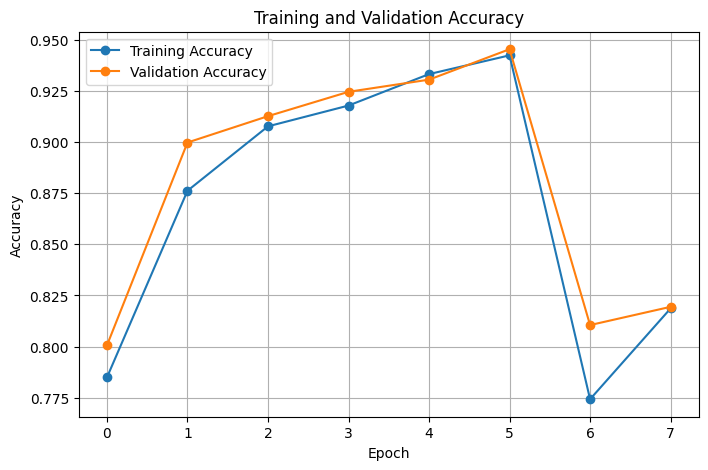

In [14]:
# Plot training and validation accuracy.

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

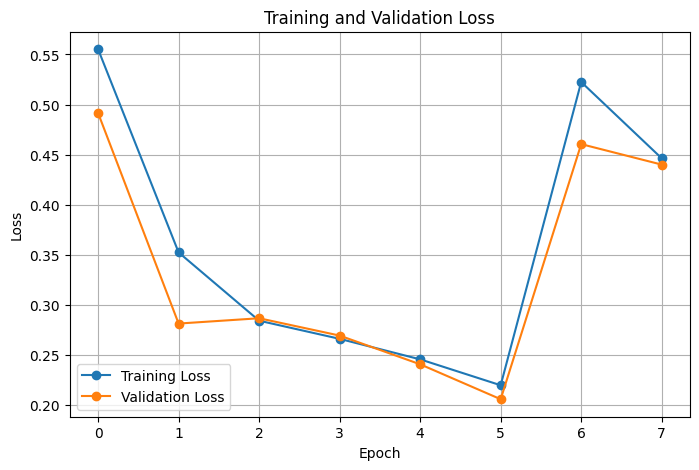

In [15]:
# Plot training and validation loss.

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 12. Model Evaluation

The trained model is evaluated on the held-out test set, which was not used during model training.

Accuracy, precision, recall, and F1-score are used to measure classification performance.

In [16]:
# Evaluate the trained model on the unseen test set.

test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1874
Test Accuracy: 0.9476


In [17]:
# Generate predictions for the test set.

y_probability = model.predict(
    X_test_pad,
    verbose=0
)

# Convert probabilities into binary predictions.
y_pred = (y_probability >= 0.5).astype(int).flatten()

# Generate a detailed classification report.
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Phishing/Malicious"],
        digits=4
    )
)

                    precision    recall  f1-score   support

        Legitimate     0.9773    0.9556    0.9663       990
Phishing/Malicious     0.8493    0.9185    0.8826       270

          accuracy                         0.9476      1260
         macro avg     0.9133    0.9370    0.9244      1260
      weighted avg     0.9499    0.9476    0.9484      1260



In [18]:
# Calculate individual evaluation metrics.

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9476
Precision: 0.8493
Recall   : 0.9185
F1-Score : 0.8826


## 13. Confusion Matrix

A confusion matrix is used to visualize the number of correctly and incorrectly classified emails for each class.

It provides a more detailed view of the model's ability to distinguish legitimate emails from phishing/malicious emails.

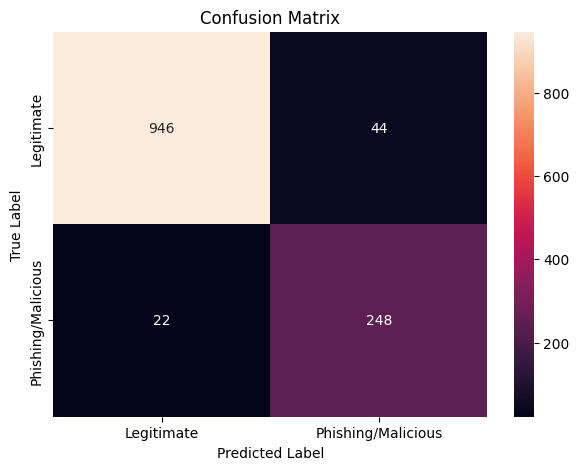

Confusion Matrix:
[[946  44]
 [ 22 248]]


In [19]:
# Compute and visualize the confusion matrix.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Phishing/Malicious"],
    yticklabels=["Legitimate", "Phishing/Malicious"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(cm)

## 14. Sample Email Predictions

The trained model is tested with previously unseen email messages to demonstrate how the classifier can be used to predict whether a new email is legitimate or phishing/malicious.

In [20]:
# Function to classify a new email.

def predict_email(email):
    cleaned_email = clean_text(email)

    sequence = tokenizer.texts_to_sequences([cleaned_email])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probability = float(
        model.predict(padded_sequence, verbose=0)[0][0]
    )

    prediction = (
        "Phishing / Malicious"
        if probability >= 0.5
        else "Legitimate"
    )

    print("Email:")
    print(email)
    print()
    print("Prediction:", prediction)
    print("Phishing Probability:", round(probability, 4))

In [21]:

# Example 1: suspicious email.

predict_email(
    "URGENT! Your bank account has been suspended. "
    "Click here immediately to verify your password and account."
)

Email:
URGENT! Your bank account has been suspended. Click here immediately to verify your password and account.

Prediction: Phishing / Malicious
Phishing Probability: 0.8699


In [22]:

# Example 2: legitimate-looking email.

predict_email(
    "Hi Rahul, the project meeting is scheduled for Monday at 10 AM. "
    "Please review the attached report before the meeting."
)

Email:
Hi Rahul, the project meeting is scheduled for Monday at 10 AM. Please review the attached report before the meeting.

Prediction: Phishing / Malicious
Phishing Probability: 0.8699
